In [161]:
import pandas as pd
import numpy as np

In [162]:
df=pd.read_csv(r'C:\Users\hp\Desktop\5thsem_ojt\project1_diabetes\data\processed\project1_diabetes_cleaned.csv',parse_dates=['last_checkup_date'])

In [163]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [164]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

In [165]:
df.shape

(950, 14)

creat an age band feature

In [166]:
df["age_band"] = pd.cut(
    df["age"],bins=[0,35,55,120]   ,labels=("youth","middle-aged","senior")
)

In [167]:
df["age_band"].value_counts()

age_band
senior         372
middle-aged    326
youth          252
Name: count, dtype: int64

create a bmi category feature

In [168]:
df['bmi_category']=pd.cut(
    df['bmi'],
    bins=[0,18.5,25,30,100],
    labels=('underweight','normal','overweight','obese'))

In [169]:
df['bmi_category'].value_counts()

bmi_category
obese          553
overweight     235
normal         124
underweight     38
Name: count, dtype: int64

In [170]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
age_band                   category
bmi_category               category
dtype: object

In [171]:
df['glucose_band']=pd.cut(
    df['glucose'],
    bins=[0,100,126,300],
    labels=('normal','prediabetic','diabetic'))

In [172]:
df['glucose_band'].value_counts()

glucose_band
diabetic       349
prediabetic    337
normal         264
Name: count, dtype: int64

In [173]:
df['insulin_glucose_ratio']=df['insulin']/df['glucose']

In [174]:
df['insulin_glucose_ratio'].head(10)

0    1.000000
1    0.274510
2    1.119718
3    1.024793
4    0.943925
5    0.855172
6    1.789474
7    0.826667
8    1.751938
9    1.248447
Name: insulin_glucose_ratio, dtype: float64

check ratio for impossible values

In [175]:
df['insulin_glucose_ratio'].describe()

count    950.000000
mean       1.213361
std        1.179203
min        0.054348
25%        0.727225
50%        1.059829
75%        1.512831
max       22.745763
Name: insulin_glucose_ratio, dtype: float64

In [176]:
np.isinf(df['insulin_glucose_ratio']).sum()

np.int64(0)

In [177]:
df['prgnencies_age_rate']=df['pregnancies']/df['age']

In [178]:
df['prgnencies_age_rate'].head()

0    0.000000
1    0.000000
2    0.000000
3    0.102941
4    0.000000
Name: prgnencies_age_rate, dtype: float64

In [179]:
df['prgnencies_age_rate'].describe()

count    950.000000
mean       0.042787
std        0.067440
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: prgnencies_age_rate, dtype: float64

In [180]:
reference_date=df['last_checkup_date'].max()

In [181]:
df['days_since_checkup']= (reference_date - df['last_checkup_date']).dt.days

In [182]:
df['days_since_checkup']

0      618
1      239
2      539
3      258
4      336
      ... 
945    407
946    588
947    570
948    206
949    445
Name: days_since_checkup, Length: 950, dtype: int64

create a categorical combination feature

In [183]:
df['activity_smoker']=df['physical_activity']+'/'+df['smoker']

In [184]:
df['activity_smoker']

0       Unknown/NO
1       Medium/YES
2      Low/UNKNOWN
3      Unknown/YES
4           Low/NO
          ...     
945     Medium/YES
946        Low/YES
947         Low/NO
948        High/NO
949      Medium/NO
Name: activity_smoker, Length: 950, dtype: str

In [185]:
df['activity_smoker'].value_counts()

activity_smoker
Medium/NO          207
High/NO            195
Low/NO             180
Low/YES             93
Medium/YES          90
High/YES            85
Unknown/NO          36
High/UNKNOWN        22
Unknown/YES         17
Medium/UNKNOWN      12
Low/UNKNOWN          9
Unknown/UNKNOWN      4
Name: count, dtype: int64

list inventory every new columns

In [186]:
# age band= age #
# bmi category=bmi #
# glucose band = glucose #
# insulin glucose ratio =insulin/glucose #
# pregnencies age rate =pregnencies/age #
# activity smoker=physical activity+smoker #d
# days since check up=reference date-last check up date #

In [187]:
df.shape

(950, 21)

In [188]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose_ratio,prgnencies_age_rate,days_since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle-aged,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,middle-aged,overweight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,overweight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,prediabetic,0.943925,0.000000,336,Low/NO
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,...,YES,2024-01-10,0,middle-aged,normal,diabetic,0.855172,0.000000,353,High/YES
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,...,NO,2023-12-25,0,senior,overweight,normal,1.789474,0.086207,369,High/NO
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,...,NO,2024-06-20,1,senior,obese,diabetic,0.826667,0.051724,191,Medium/NO
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,...,UNKNOWN,2023-10-15,1,youth,normal,diabetic,1.751938,0.187500,440,High/UNKNOWN
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,...,YES,2023-12-22,1,senior,obese,diabetic,1.248447,0.000000,372,Medium/YES


# EXPLORATORY ANALYSIS


In [189]:

numeric_cols=['age','pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi','diabetes_pedigree']
df.groupby('outcome')[numeric_cols].mean()

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,,
0,47.874446,1.828656,112.193501,72.350074,26.370753,131.490399,30.941359,0.441821
1,54.798535,1.915751,131.846154,71.930403,26.047619,132.388278,32.516850,0.511564


In [190]:
engineered_numeric=['insulin_glucose_ratio','prgnencies_age_rate','days_since_checkup']
df.groupby('outcome')[engineered_numeric].mean()

,insulin_glucose_ratio,prgnencies_age_rate,days_since_checkup
outcome,,,
0,1.271313,0.044392,350.304284
1,1.069647,0.038809,366.534799


rank everything together

In [191]:
group_means=df.groupby('outcome')[numeric_cols+engineered_numeric].mean().T
group_means['gap']=(group_means[1]-group_means[0]).abs()
group_means.sort_values('gap',ascending=False)

outcome,0,1,gap
glucose,112.193501,131.846154,19.652653
days_since_checkup,350.304284,366.534799,16.230515
age,47.874446,54.798535,6.924089
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose_ratio,1.271313,1.069647,0.201667
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743


In [192]:
#glucose#
#days_since_checkup#
#age#


In [193]:
pd.crosstab(df['age_band'],df['outcome'],normalize='index')

outcome,0,1
age_band,,
youth,0.789683,0.210317
middle-aged,0.766871,0.233129
senior,0.612903,0.387097


In [194]:
pd.crosstab(df['bmi_category'],df['outcome'],normalize='index')

outcome,0,1
bmi_category,,
underweight,0.763158,0.236842
normal,0.750000,0.250000
overweight,0.770213,0.229787
obese,0.676311,0.323689


cross-tabulate glucose band against outcome

In [195]:
pd.crosstab(df['glucose_band'],df['outcome'],normalize='index')

outcome,0,1
glucose_band,,
normal,0.901515,0.098485
prediabetic,0.715134,0.284866
diabetic,0.567335,0.432665


In [196]:
import matplotlib.pyplot as plt

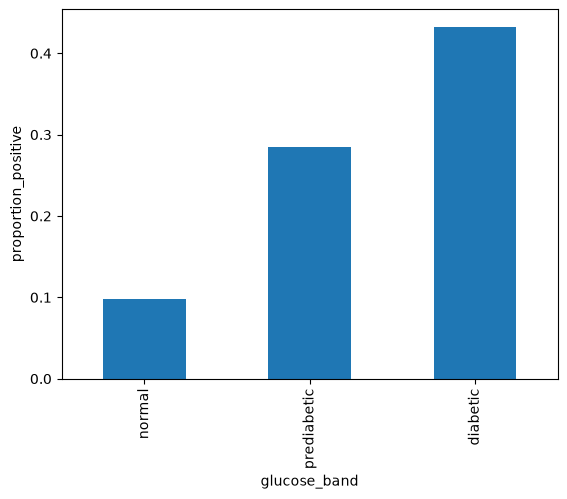

In [197]:
ax=pd.crosstab(df['glucose_band'],df['outcome'],normalize='index')[1].plot(kind='bar')
ax.set_xlabel('glucose_band')
ax.set_ylabel('proportion_positive')
plt.show()

In [198]:
df.to_csv(r'C:\Users\hp\Desktop\5thsem_ojt\project1_diabetes\data\processed\aman_p1w2_features.csv',index=False)

In [199]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_band,insulin_glucose_ratio,prgnencies_age_rate,days_since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle-aged,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,middle-aged,overweight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,overweight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,prediabetic,0.943925,0.000000,336,Low/NO
